<a href="https://colab.research.google.com/github/DwiAyuniRohana/data-science-2025/blob/main/Pertemuan4_DwiAyuni_250401020173.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Dwi Ayuni Rohana  
**NIM:** 250401020173  
**Prodi:** Informatika


===== INFORMASI DATASET =====
Shape Dataset : (150, 5)

===== TIPE DATA =====
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

===== 5 DATA TERATAS =====
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

===== STATISTIK DESKRIPTIF =====
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1

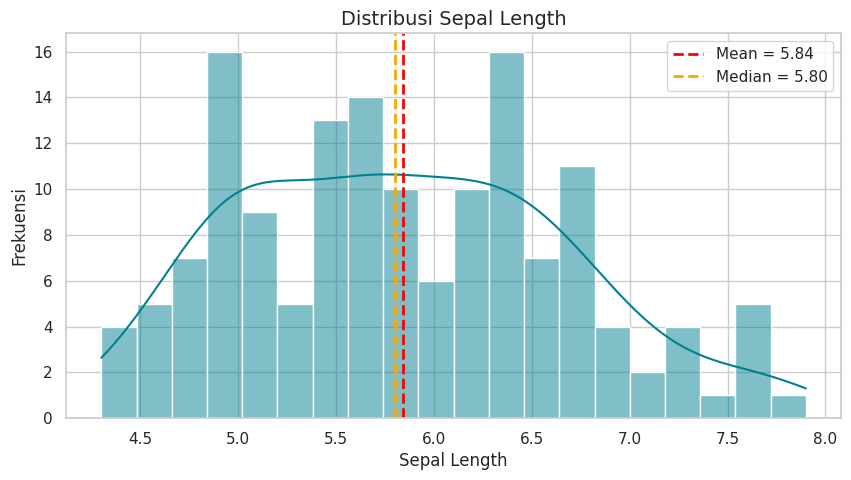


===== INTERPRETASI DISTRIBUSI =====
Nilai Skewness : 0.315
Distribusi cenderung miring ke kanan (positively skewed).


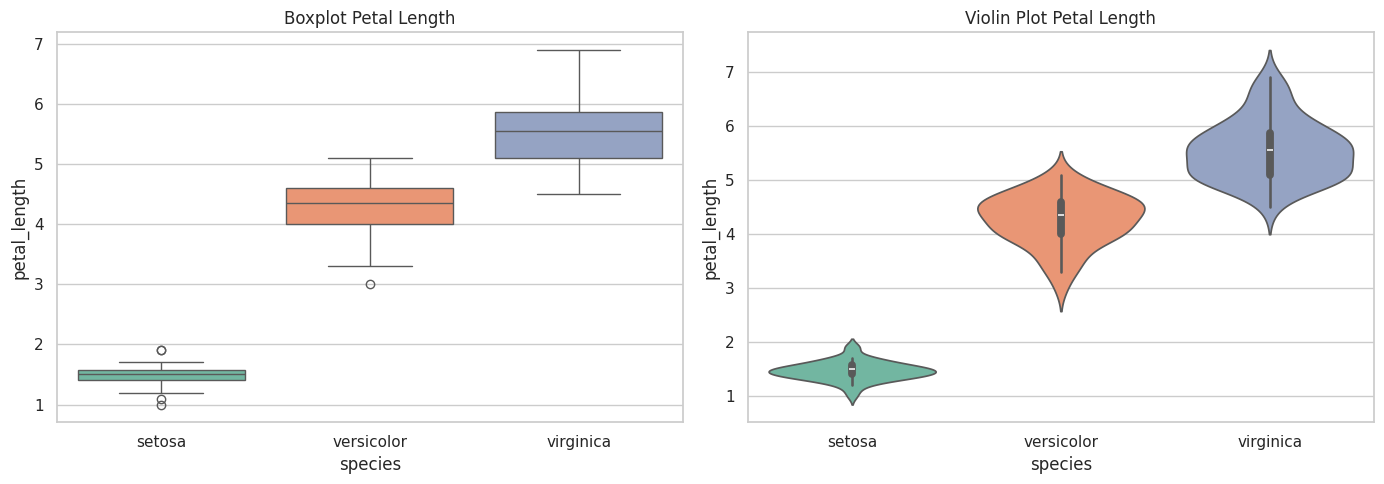


===== ANALISIS PETAL LENGTH =====
             mean  max  min    std
species                           
setosa      1.462  1.9  1.0  0.174
versicolor  4.260  5.1  3.0  0.470
virginica   5.552  6.9  4.5  0.552

Spesies dengan nilai terbesar : virginica
Spesies dengan nilai terkecil : setosa
Spesies paling tersebar       : virginica

===== MATRIKS KORELASI =====
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428


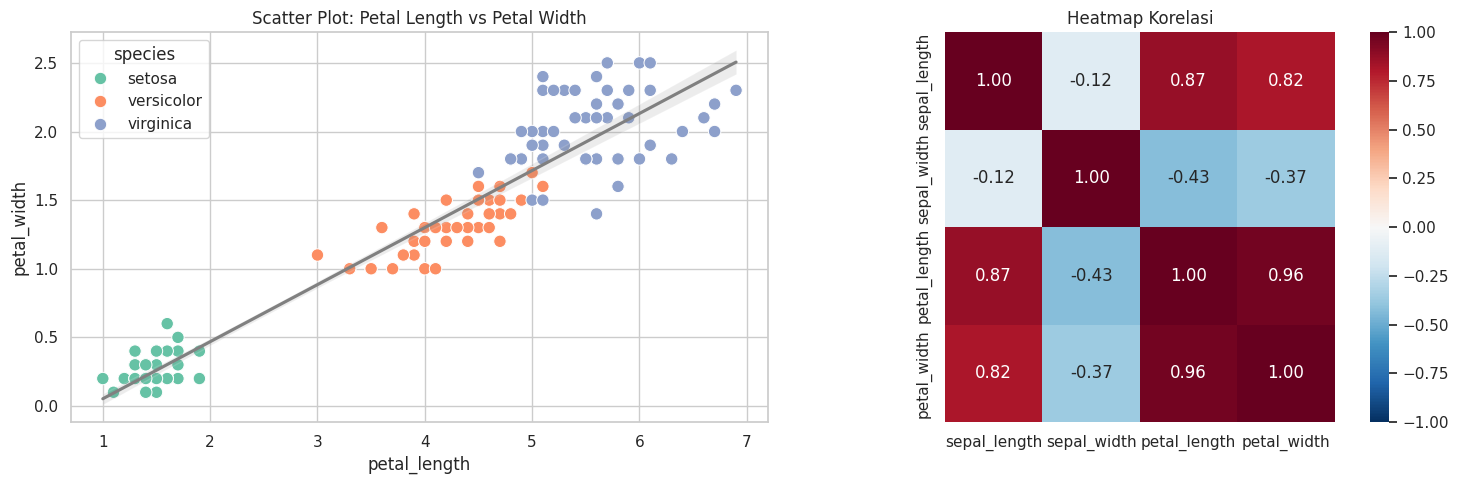

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid')

# ==============================================================================
# LANGKAH 1 : LOAD & INSPECT DATASET
# ==============================================================================
# Load dataset iris resmi bawaan dari pustaka Seaborn
df = sns.load_dataset('iris')

print("===== INFORMASI DATASET =====")
print("Shape Dataset :", df.shape)

print("\n===== TIPE DATA =====")
print(df.dtypes)

print("\n===== 5 DATA TERATAS =====")
print(df.head())

print("\n===== STATISTIK DESKRIPTIF =====")
print(df.describe().round(3))


# ==============================================================================
# LANGKAH 2 : STATISTIK DESKRIPTIF LENGKAP
# ==============================================================================
print("\n\n===== STATISTIK DESKRIPTIF LENGKAP =====")
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name.upper()} ===')
    print(f'Mean      : {col.mean():.3f}')
    print(f'Median    : {col.median():.3f}')
    print(f'Std Dev   : {col.std():.3f}')
    print(f'Varians   : {col.var():.3f}')
    print(f'Skewness  : {col.skew():.3f}')
    print(f'Kurtosis  : {col.kurt():.3f}')


# ==============================================================================
# LANGKAH 3 : ANALISIS DISTRIBUSI (Histogram + KDE)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='#028090',
    ax=ax
)

# Garis mean
ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis median
ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length', fontsize=14)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.show()

# Interpretasi distribusi
print("\n===== INTERPRETASI DISTRIBUSI =====")
skew_value = df['sepal_length'].skew()
print(f"Nilai Skewness : {skew_value:.3f}")
if skew_value > 0:
    print("Distribusi cenderung miring ke kanan (positively skewed).")
elif skew_value < 0:
    print("Distribusi cenderung miring ke kiri (negatively skewed).")
else:
    print("Distribusi simetris.")


# ==============================================================================
# LANGKAH 4 : BOXPLOT & VIOLIN PLOT PER SPESIES
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot - SOLUSI: Pasangkan x ke hue dan set legend=False
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Boxplot Petal Length')

# Violin plot - SOLUSI: Pasangkan x ke hue dan set legend=False
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    inner='box',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

# Analisis spesies
print("\n===== ANALISIS PETAL LENGTH =====")
group_stats = df.groupby('species', observed=False)['petal_length'].agg(['mean', 'max', 'min', 'std'])
print(group_stats.round(3))

largest_species = group_stats['max'].idxmax()
smallest_species = group_stats['min'].idxmin()
widest_species = group_stats['std'].idxmax()

print(f"\nSpesies dengan nilai terbesar : {largest_species}")
print(f"Spesies dengan nilai terkecil : {smallest_species}")
print(f"Spesies paling tersebar       : {widest_species}")


# ==============================================================================
# LANGKAH 5 : MATRIKS KORELASI PEARSON
# ==============================================================================
# SOLUSI: Menggunakan numeric_only=True agar aman dari kolom teks 'species'
corr = df.corr(method='pearson', numeric_only=True)

print("\n===== MATRIKS KORELASI =====")
print(corr.round(3))

# Mencari korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f'\nKorelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}')


# ==============================================================================
# LANGKAH 6 : SCATTER PLOT & HEATMAP
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    s=80,
    ax=axes[0]
)

# Garis regresi
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)
axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')

# Heatmap korelasi
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

# Kesimpulan

Pada praktikum ini saya mempelajari cara melakukan eksplorasi awal data (Data Inspection) dan statistika deskriptif menggunakan Python, Pandas, dan Seaborn pada dataset Iris. Proses yang dilakukan meliputi memuat dataset, melihat ukuran data, memeriksa tipe data setiap kolom, menampilkan beberapa data awal, serta menghitung statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dan standar deviasi.

Temuan utama dari eksplorasi awal menunjukkan bahwa dataset Iris terdiri dari 150 baris data dengan 5 kolom, yaitu empat fitur numerik (sepal length, sepal width, petal length, dan petal width) serta satu kolom kategorikal (species). Selain itu, statistik deskriptif memberikan gambaran umum mengenai persebaran dan karakteristik setiap fitur sehingga memudahkan proses analisis lebih lanjut.

Keterbatasan pada tahap ini adalah analisis masih bersifat deskriptif dan belum mencakup visualisasi data, pengujian statistik, maupun pembangunan model machine learning. Pertanyaan yang muncul adalah apakah terdapat perbedaan yang signifikan antara masing-masing spesies Iris berdasarkan karakteristik ukuran sepal dan petal yang dimiliki.